In [ ]:
#Reference
#https://github.com/fnusatvik07/agent-builder-thinkinginglanggraph/blob/main/workbooks/10_orchestrator_worker.ipynb

**Parallelization**
1. Do multiple tasks at the same time
2. Developer predefines tasks
3. Faster execution

Use when:

a. Tasks are independent

b. Need speed

c. Multiple perspectives are useful

```text
     START
  |
  +--> joke_node
  |
  +--> story_node
  |
  +--> poem_node
          |
       combine
          |
         END

```

**Orchestrator–Workers**
1. Break a large task into smaller tasks
2. Orchestrator decides dynamically
3. Better task decomposition


Use when:

a. Task is large

b. Subtasks are unknown beforehand

c. Need planning and delegation

A manager agent first analyzes the task and then creates worker tasks
```text

User
  |
Orchestrator
  |
  +--> Intro Worker
  |
  +--> Applications Worker
  |
  +--> Future Worker
  |
  v
Merge Results
  |
 END       

```

**Parallelization** = Same input → Multiple independent tasks → Run simultaneously

**Orchestrator–Workers** = Manager → Creates tasks → Workers execute here tasks are dependent or sequential?

```text
Planner
   ↓
Send() creates N workers
   ↓
Workers run in parallel
   ↓
Reducer merges results
   ↓
Final output
```

**SIMPLE CODE:**

In [2]:
from typing import TypedDict
#from langgraph.constants import Send
from langgraph.types import Send

class State(TypedDict):
    topics: list[str]

# Planner node
def planner(state: State):
    return [
        Send("worker", {"topic": topic})
        for topic in state["topics"]
    ]

# Worker node
def worker(state):
    print(f"Writing about: {state['topic']}")
    return {}

In [4]:
from langgraph.graph import StateGraph, START, END

# Build graph
builder = StateGraph(State)

builder.add_node("worker", worker)

# Dynamic parallelization
builder.add_conditional_edges(
    START,
    planner,
    ["worker"]
)

builder.add_edge("worker", END)

graph = builder.compile()

graph.invoke({
    "topics": ["AI", "Machine Learning", "LangGraph"]
})

Writing about: AI
Writing about: Machine Learning
Writing about: LangGraph


{'topics': ['AI', 'Machine Learning', 'LangGraph']}

**WORKBOOK:** easy way

In [5]:
!pip install langchain langchain-groq langgraph python-dotenv ipython --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 87.6 MB/s eta 0:00:00


In [9]:
import os
from dotenv import load_dotenv
load_dotenv('/content/.env.txt')
print("Keys loaded:", "GROQ_API_KEY")

Keys loaded: GROQ_API_KEY


In [10]:
import os, operator
from pathlib import Path
from typing import Annotated, List, TypedDict

from pydantic import BaseModel, Field
from langchain.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send


In [8]:
from pathlib import Path
from IPython.display import Image, display, Markdown

OUT = Path("graph_out_orchestrator")
OUT.mkdir(exist_ok=True)

def save_graph(app, name):
    graph = app.get_graph()

    (OUT / f"{name}.mmd").write_text(graph.draw_mermaid())

    try:
        (OUT / f"{name}.png").write_bytes(graph.draw_mermaid_png())
        print(f"Saved: {name}.png")
    except Exception:
        print("PNG generation failed")

def show_graph(name):
    png = OUT / f"{name}.png"

    if png.exists():
        display(Image(filename=png))
    else:
        display(Markdown(f"Open `graph_out/{name}.mmd` in mermaid.live"))

In [11]:
# Initialize Groq model
from langchain.chat_models import init_chat_model

In [12]:
llm = init_chat_model(
    "groq:llama-3.3-70b-versatile",
    temperature=0
)

print("LLM ready")

LLM ready


**The planner schema**
The orchestrator returns a list of Section objects. Each becomes one worker.

In [13]:
#These are just Pydantic schemas that define the structure of the LLM's output.
#No graph state involved.
class Section(BaseModel):
    name: str = Field(description="Name of this section.")
    description: str = Field(description="Brief overview of what this section covers.")

class Sections(BaseModel): # previous class as input
    sections: List[Section] = Field(description="Sections of the report. Keep to 2-3 short sections for a teaching demo.")

planner = llm.with_structured_output(Sections)

demo_plan = planner.invoke([
    SystemMessage(content="Generate a short plan for the report. Return 2 or 3 sections only."),
    HumanMessage(content="Topic: a beginner's guide to vector databases"),
])

for s in demo_plan.sections:
    print(f"- {s.name}: {s.description}")

- Introduction to Vector Databases: Overview of vector databases, their purpose, and benefits
- Key Concepts and Technologies: Explanation of key concepts, such as vector embeddings and similarity search, and technologies used in vector databases
- Getting Started with Vector Databases: Step-by-step guide to setting up and using a vector database, including popular tools and libraries


In [15]:
print(dir(llm))# 'with_structured_output

['InputType', 'OutputType', '__abstractmethods__', '__annotations__', '__class__', '__class_getitem__', '__class_vars__', '__copy__', '__deepcopy__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__fields__', '__fields_set__', '__format__', '__ge__', '__get_pydantic_core_schema__', '__get_pydantic_json_schema__', '__getattr__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__iter__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__or__', '__orig_bases__', '__parameters__', '__pretty__', '__private_attributes__', '__pydantic_complete__', '__pydantic_computed_fields__', '__pydantic_core_schema__', '__pydantic_custom_init__', '__pydantic_decorators__', '__pydantic_extra__', '__pydantic_fields__', '__pydantic_fields_set__', '__pydantic_generic_metadata__', '__pydantic_init_subclass__', '__pydantic_on_complete__', '__pydantic_parent_namespace__', '__pydantic_post_init__', '__pydantic_private__', '__pydantic_root_model__',

State, with a reducer on the worker output

**Two states**. State is the orchestrator-level state. WorkerState is what a single worker receives.

**The reducer** matters here: all workers write to completed_sections.

Without Annotated[list, operator.add], two parallel writes of [a] and [b] would race.

With the reducer, LangGraph concatenates to [a, b].


In [18]:
class State(TypedDict):
    topic: str
    sections: list[Section] #not sections
    completed_sections: Annotated[list[str], operator.add]
    final_report: str

class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list[str], operator.add]

In [ ]:
#Nodes

In [ ]:
'''
def orchestrator(state: State):
    print("[orchestrator] planning")
    plan = planner.invoke([
        SystemMessage(content="Generate a plan for the report. Return 2 or 3 short sections."),
        HumanMessage(content=f"Report topic: {state['topic']}"),
    ])
    print(f"[orchestrator] planned {len(plan.sections)} sections: {[s.name for s in plan.sections]}")
    return {"sections": plan.sections}

def llm_call(state: WorkerState):
    section = state["section"]
    print(f"[worker] writing: {section.name}")
    body = llm.invoke([
        SystemMessage(content="Write one short paragraph for this section. No preamble. Use markdown."),
        HumanMessage(content=f"Section name: {section.name}\nDescription: {section.description}"),
    ])
    return {"completed_sections": [body.content]}

def synthesizer(state: State):
    print(f"[synth] joining {len(state['completed_sections'])} sections")
    return {"final_report": "\n\n---\n\n".join(state["completed_sections"])}

def assign_workers(state: State):
    """Conditional edge: emit one Send per section. This is the dynamic fan-out."""
    return [Send("llm_call", {"section": s}) for s in state["sections"]]

'''

```text

Main State
{
    "topic": "Vector Databases"
}
       │
       ▼
orchestrator(state)
       │
       ▼
returns

{
    "sections": [
        Section 1,
        Section 2,
        Section 3
    ]
}
       │
       ▼
Send()
       │
       ├── Worker 1 gets
       │   {"section": Section 1}
       │
       ├── Worker 2 gets
       │   {"section": Section 2}
       │
       └── Worker 3 gets
           {"section": Section 3}
```

In [19]:
def orchestrator(state: State):
    plan = planner.invoke([
        SystemMessage(content="Generate a plan for the report. Return 2 or 3 short sections."),
        HumanMessage(content=f"Report topic: {state['topic']}"),
    ])
    return {"sections": plan.sections}


def llm_call(state: WorkerState):#llm_call is one function, shared by all workers
#Each worker calls the same function but with a different input — so each gets a different section,
#calls the LLM with that section's details, and returns its own paragraph
    section = state["section"]
    body = llm.invoke([
        SystemMessage(content="Write one short paragraph for this section. No preamble. Use markdown."),
        HumanMessage(content=f"Section name: {section.name}\nDescription: {section.description}"),
    ])
    return {"completed_sections": [body.content]}


def synthesizer(state: State):
    return {"final_report": "\n\n---\n\n".join(state["completed_sections"])}


def assign_workers(state: State) -> list[Send]:
    """Fan-out: one worker per section."""
    return [Send("llm_call", {"section": s}) for s in state["sections"]]

    '''
    def assign_workers(state: State) -> list[Send]:
    """Fan-out: one worker per section."""
    sends = []
    for s in state["sections"]:
        sends.append(Send("llm_call", {"section": s}))
    return sends
    '''


Saved: 10_orchestrator_worker.png


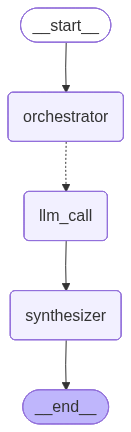

In [20]:
# Wire it
builder = StateGraph(State)

builder.add_node("orchestrator", orchestrator)
builder.add_node("llm_call", llm_call)
builder.add_node("synthesizer", synthesizer)

builder.add_edge(START, "orchestrator")
builder.add_conditional_edges("orchestrator", assign_workers, ["llm_call"])
builder.add_edge("llm_call", "synthesizer")
builder.add_edge("synthesizer", END)

app = builder.compile()
save_graph(app, "10_orchestrator_worker")
show_graph("10_orchestrator_worker")

In [21]:
result = app.invoke({
    "topic": "A short, practical guide to vector databases for beginners",
    "sections": [],
    "completed_sections": [],
    "final_report": "",
})
print("\n========== FINAL REPORT ==========\n")
print(result["final_report"][:1500])


========== FINAL REPORT ==========

### Introduction to Vector Databases
Vector databases are specialized databases designed to efficiently store, index, and query large datasets of dense vectors, typically generated by machine learning models. They enable fast similarity searches, allowing users to find the most similar items in a dataset, and are particularly useful in applications such as image and text search, recommendation systems, and natural language processing. By leveraging approximate nearest neighbors (ANN) search algorithms and indexing techniques, vector databases provide a scalable and performant solution for managing and querying complex vector data.

---

### Use Cases and Applications
Vector databases have numerous practical applications, including **image and text search**, where they enable efficient similarity searches and semantic retrievals. They are also used in **recommendation systems**, allowing for personalized suggestions based on complex patterns and rela

In [24]:
#Functional API equivalent
#Without Send. Build the futures with a list comprehension and join them with .result().

from langgraph.func import entrypoint, task

@task
def orchestrator_t(topic: str):
    return planner.invoke([
        SystemMessage(content="Generate a plan for the report. 2 or 3 short sections."),
        HumanMessage(content=f"Report topic: {topic}"),
    ]).sections

@task
def llm_call_t(section: Section):
    return llm.invoke([
        SystemMessage(content="Write one short paragraph for this section."),
        HumanMessage(content=f"Section: {section.name}. Description: {section.description}"),
    ]).content

@task
def synthesizer_t(completed: list[str]):
    return "\n\n---\n\n".join(completed)

@entrypoint()
def orchestrator_worker_func(topic: str):

    # Step 1: Plan the sections (wait for result)
    sections = orchestrator_t(topic).result()

    # Step 2: Fire all writers in parallel (don't wait yet)
    futures = [llm_call_t(s) for s in sections]

    # Step 3: Collect all results, then join into final report
    completed = [f.result() for f in futures]
    final_report = synthesizer_t(completed).result()

    return final_report


final_report = orchestrator_worker_func.invoke("A short guide to LangGraph for beginners")
print(final_report[:1200])



LangGraph is a revolutionary language model designed to process and generate human-like language, enabling efficient and effective communication. Its primary purpose is to understand and respond to user input in a natural and intuitive way, making it an invaluable tool for various applications such as language translation, text summarization, and conversational interfaces. By leveraging advanced algorithms and machine learning techniques, LangGraph aims to bridge the gap between human language and computer understanding, facilitating seamless interactions and unlocking new possibilities for language-based technologies.

---

To get started with LangGraph, begin by downloading and installing the software from the official website, then launch the application and create a new project by selecting the desired language and graph type. Next, import your data or create a new dataset from scratch, and use the intuitive interface to customize the graph's appearance and settings. Once your grap

**When to use StateGraph** — complex workflows with conditional routing, human-in-the-loop interrupts, checkpointing, memory across sessions, and subgraphs. It gives you full control.

**When to use Functional API** — straightforward pipelines where tasks flow in a clear sequence with optional parallelism. Less control, far less code.